# Multi-Layer Fully Connected Networks on CIFAR-10

This notebook adapts the original CS231n `FullyConnectedNets.ipynb` exercise to the **local repo-friendly workflow** used by the other notebooks in `demos/`.

We keep the assignment's experimentation flow, but make it work directly with this repository:
- run locally from `demos/`
- import reusable implementations from `src/`
- load CIFAR-10 from the repo's `data/` directory
- preserve the original gradient checks, optimizer experiments, and model-tuning tasks

## Related source files
- `src/models/fc_net.py`
- `src/layers.py`
- `src/optim.py`
- `src/utils/data.py`
- `src/utils/gradient_check.py`
- `src/utils/solver.py`


## 0. Why deeper fully connected networks?

A two-layer network is already expressive enough to learn nonlinear decision boundaries, but deeper fully connected networks let us compose several affine + nonlinearity blocks into a richer function class.

That extra depth introduces two practical challenges that this notebook focuses on:
- **implementation discipline**: every layer must expose a clean forward and backward interface;
- **optimization stability**: deeper networks are more sensitive to initialization and update rules.

The assignment is structured around those two ideas: first make the modular implementation correct, then make optimization work well enough to train a useful classifier on CIFAR-10.


## 1. Setup

The setup below mirrors the earlier repo notebooks:
- add the repository root to `sys.path`,
- import the local model, solver, and gradient-check helpers from `src/`,
- create the `artifacts/` directory for saved models,
- and configure plotting defaults for notebook work.


In [1]:
from __future__ import print_function

import sys
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from src.models.fc_net import FullyConnectedNet
from src.utils.data import load_CIFAR10
from src.utils.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from src.utils.solver import Solver

(repo_root / 'artifacts').mkdir(parents=True, exist_ok=True)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2


def rel_error(x, y):
    """Return the maximum relative error."""
    return np.max(np.abs(x - y) / np.maximum(1e-8, np.abs(x) + np.abs(y)))


## 2. Load and preprocess CIFAR-10

The original notebook used `get_CIFAR10_data()` from the course codebase. Here we reproduce the same preprocessing locally:

1. load raw CIFAR-10 from `data/`,
2. download it automatically if it is missing,
3. split into training / validation / test subsets,
4. subtract the mean training image,
5. transpose images to channel-first format `(N, 3, 32, 32)`.

This keeps the later exercise cells close to the original notebook while matching the structure of this repo.


In [2]:
cifar10_dir = repo_root / 'data' / 'cifar-10-batches-py'

if not cifar10_dir.exists():
    print('CIFAR-10 dataset not found. Downloading...')

    data_dir = repo_root / 'data'
    data_dir.mkdir(parents=True, exist_ok=True)

    url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
    archive_path = data_dir / 'cifar-10-python.tar.gz'

    urllib.request.urlretrieve(url, archive_path)

    print('Extracting dataset...')
    with tarfile.open(archive_path, 'r:gz') as tar:
        tar.extractall(path=data_dir)

    print('Download complete.')


def get_CIFAR10_data_local(
    num_training=49000,
    num_validation=1000,
    num_test=1000,
    subtract_mean=True,
):
    """Match the original assignment preprocessing using the local repo layout."""
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]

    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]

    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    if subtract_mean:
        mean_image = np.mean(X_train, axis=0)
        X_train = X_train - mean_image
        X_val = X_val - mean_image
        X_test = X_test - mean_image

    X_train = X_train.transpose(0, 3, 1, 2).copy()
    X_val = X_val.transpose(0, 3, 1, 2).copy()
    X_test = X_test.transpose(0, 3, 1, 2).copy()

    return {
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'X_test': X_test,
        'y_test': y_test,
    }


data = get_CIFAR10_data_local()
for k, v in list(data.items()):
    print(f'{k}: {v.shape}')


X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## 3. Initial loss and gradient check

Start by reading through `FullyConnectedNet` in `src/models/fc_net.py`.

At this stage, the core task is to implement:
- parameter initialization,
- the forward pass through an arbitrary number of hidden layers,
- and the backward pass that produces gradients for all parameters.

The numeric gradient check below is the quickest sanity test for whether those pieces are wired correctly. As in the original assignment, relative errors around `1e-7` or smaller are a good sign.


In [3]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print('Running check with reg = ', reg)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64,
    )

    loss, grads = model.loss(X, y)
    print('Initial loss: ', loss)

    # Most errors should be around e-7 or smaller.
    # It is acceptable to see W2 near e-5 when reg = 0.
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f'{name} relative error: {rel_error(grad_num, grads[name])}')


Running check with reg =  0
Initial loss:  2.300479089768492
W1 relative error: 1.0252674442610356e-07
W2 relative error: 2.2120479308074287e-05
W3 relative error: 4.5623278305506856e-07
b1 relative error: 4.660094557753541e-09
b2 relative error: 2.085654124402131e-09
b3 relative error: 1.689724888469736e-10
Running check with reg =  3.14
Initial loss:  7.052114776533016
W1 relative error: 3.904542008453064e-09
W2 relative error: 6.86942277940646e-08
W3 relative error: 3.483989217647104e-08
b1 relative error: 1.4752429506250483e-08
b2 relative error: 1.4615869332918208e-09
b3 relative error: 1.3200479211447775e-10


## 4. Can the model overfit a tiny dataset?

A useful debugging trick is to deliberately overfit a very small training set. If optimization and backpropagation are implemented correctly, a sufficiently expressive network should drive the training accuracy to 100% on 50 examples.

We first try a three-layer network, then a deeper five-layer one. The deeper model is usually more sensitive to learning rate and initialization scale, so this is also a practical test of optimization stability.


(Iteration 1 / 40) loss: 2.363364
(Epoch 0 / 20) train acc: 0.020000; val_acc: 0.105000
(Epoch 1 / 20) train acc: 0.020000; val_acc: 0.106000
(Epoch 2 / 20) train acc: 0.020000; val_acc: 0.110000
(Epoch 3 / 20) train acc: 0.020000; val_acc: 0.110000
(Epoch 4 / 20) train acc: 0.040000; val_acc: 0.109000
(Epoch 5 / 20) train acc: 0.040000; val_acc: 0.111000
(Iteration 11 / 40) loss: 2.270022
(Epoch 6 / 20) train acc: 0.040000; val_acc: 0.111000
(Epoch 7 / 20) train acc: 0.060000; val_acc: 0.112000
(Epoch 8 / 20) train acc: 0.060000; val_acc: 0.111000
(Epoch 9 / 20) train acc: 0.040000; val_acc: 0.110000
(Epoch 10 / 20) train acc: 0.040000; val_acc: 0.109000
(Iteration 21 / 40) loss: 2.309562
(Epoch 11 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 12 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 13 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 14 / 20) train acc: 0.060000; val_acc: 0.110000
(Epoch 15 / 20) train acc: 0.060000; val_acc: 0.113000
(Iteration 31 / 40) loss: 

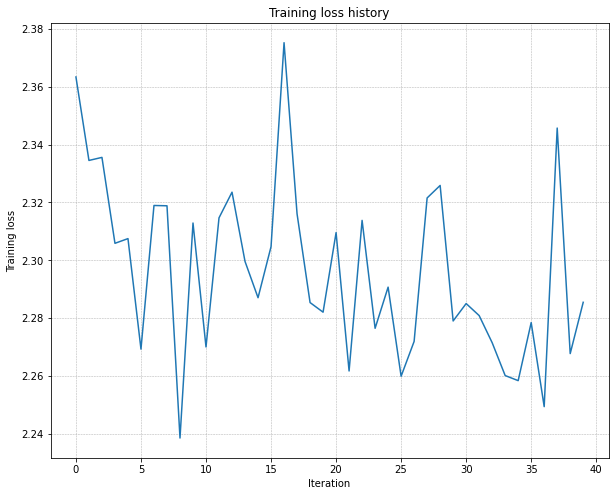

In [4]:
# TODO: Use a three-layer net to overfit 50 training examples by
# tweaking the learning rate and initialization scale.

num_train = 50
small_data = {
    'X_train': data['X_train'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val': data['X_val'],
    'y_val': data['y_val'],
}

weight_scale = 1e-2   # Experiment with this.
learning_rate = 1e-4  # Experiment with this.

model = FullyConnectedNet(
    [100, 100],
    weight_scale=weight_scale,
    dtype=np.float64,
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule='sgd',
    optim_config={'learning_rate': learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()


Now try a five-layer network with 100 hidden units in each hidden layer. You should still be able to overfit 50 examples within 20 epochs, but the tuning is usually less forgiving.


(Iteration 1 / 40) loss: 2.302585
(Epoch 0 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 1 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 2 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 3 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 4 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 5 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 11 / 40) loss: 2.301962
(Epoch 6 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 7 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 8 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 9 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 10 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 21 / 40) loss: 2.301859
(Epoch 11 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 12 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 14 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 15 / 20) train acc: 0.160000; val_acc: 0.079000
(Iteration 31 / 40) loss: 

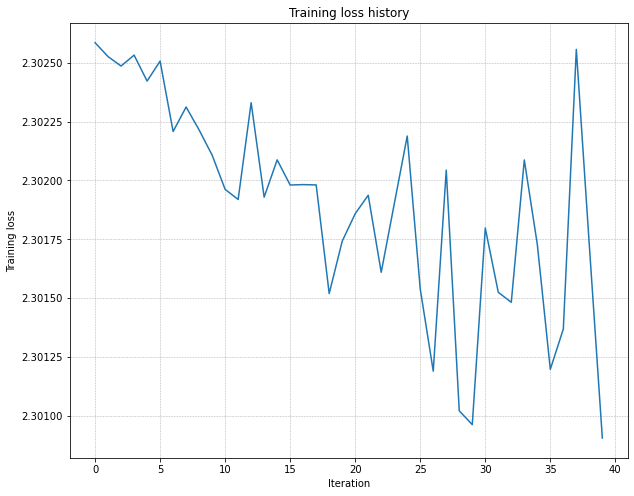

In [5]:
# TODO: Use a five-layer net to overfit 50 training examples by
# tweaking the learning rate and initialization scale.

num_train = 50
small_data = {
    'X_train': data['X_train'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val': data['X_val'],
    'y_val': data['y_val'],
}

learning_rate = 2e-3  # Experiment with this.
weight_scale = 1e-5   # Experiment with this.

model = FullyConnectedNet(
    [100, 100, 100, 100],
    weight_scale=weight_scale,
    dtype=np.float64,
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule='sgd',
    optim_config={'learning_rate': learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()


### Inline Question 1

Did you notice anything about the comparative difficulty of training the three-layer network versus the five-layer network? Which network is more sensitive to the initialization scale, and why?

**Answer.**

The five-layer network is usually more sensitive. With more stacked affine and ReLU blocks, small changes in the initialization scale get amplified across depth: activations can shrink toward zero, blow up, or leave too many ReLUs inactive. That makes the deeper network harder to optimize with plain SGD, while the shallower three-layer network tends to tolerate a wider range of scales.


## 5. Update rules

So far we have used plain stochastic gradient descent. For deeper networks, optimization often improves significantly once we add momentum or adaptive per-parameter step sizes.

In this repo those update rules live in `src/optim.py`. The next sections mirror the original assignment: first verify each optimizer numerically, then compare training behavior on the same deep network.


## 6. SGD + Momentum

Implement `sgd_momentum` in `src/optim.py`, then run the reference check below. You should see errors around `1e-8` or smaller.


In [6]:
from src.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N * D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N * D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N * D).reshape(N, D)

config = {'learning_rate': 1e-3, 'velocity': v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
    [0.1406, 0.20738947, 0.27417895, 0.34096842, 0.40775789],
    [0.47454737, 0.54133684, 0.60812632, 0.67491579, 0.74170526],
    [0.80849474, 0.87528421, 0.94207368, 1.00886316, 1.07565263],
    [1.14244211, 1.20923158, 1.27602105, 1.34281053, 1.4096],
])
expected_velocity = np.asarray([
    [0.5406, 0.55475789, 0.56891579, 0.58307368, 0.59723158],
    [0.61138947, 0.62554737, 0.63970526, 0.65386316, 0.66802105],
    [0.68217895, 0.69633684, 0.71049474, 0.72465263, 0.73881053],
    [0.75296842, 0.76712632, 0.78128421, 0.79544211, 0.8096],
])

print('next_w error: ', rel_error(next_w, expected_next_w))
print('velocity error: ', rel_error(expected_velocity, config['velocity']))


next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


Once momentum is implemented, compare it against vanilla SGD on a six-layer network. The loss should usually fall faster with momentum.


Running with  sgd
(Iteration 1 / 200) loss: 2.559978
(Epoch 0 / 5) train acc: 0.104000; val_acc: 0.107000
(Iteration 11 / 200) loss: 2.356069
(Iteration 21 / 200) loss: 2.214091
(Iteration 31 / 200) loss: 2.205928
(Epoch 1 / 5) train acc: 0.225000; val_acc: 0.193000
(Iteration 41 / 200) loss: 2.132095
(Iteration 51 / 200) loss: 2.118950
(Iteration 61 / 200) loss: 2.116443
(Iteration 71 / 200) loss: 2.132549
(Epoch 2 / 5) train acc: 0.298000; val_acc: 0.260000
(Iteration 81 / 200) loss: 1.977227
(Iteration 91 / 200) loss: 2.007528
(Iteration 101 / 200) loss: 2.004762
(Iteration 111 / 200) loss: 1.885307
(Epoch 3 / 5) train acc: 0.342000; val_acc: 0.287000
(Iteration 121 / 200) loss: 1.891413
(Iteration 131 / 200) loss: 1.924095
(Iteration 141 / 200) loss: 1.957629
(Iteration 151 / 200) loss: 1.964866
(Epoch 4 / 5) train acc: 0.320000; val_acc: 0.305000
(Iteration 161 / 200) loss: 1.801929
(Iteration 171 / 200) loss: 1.971967
(Iteration 181 / 200) loss: 1.661503
(Iteration 191 / 200) los

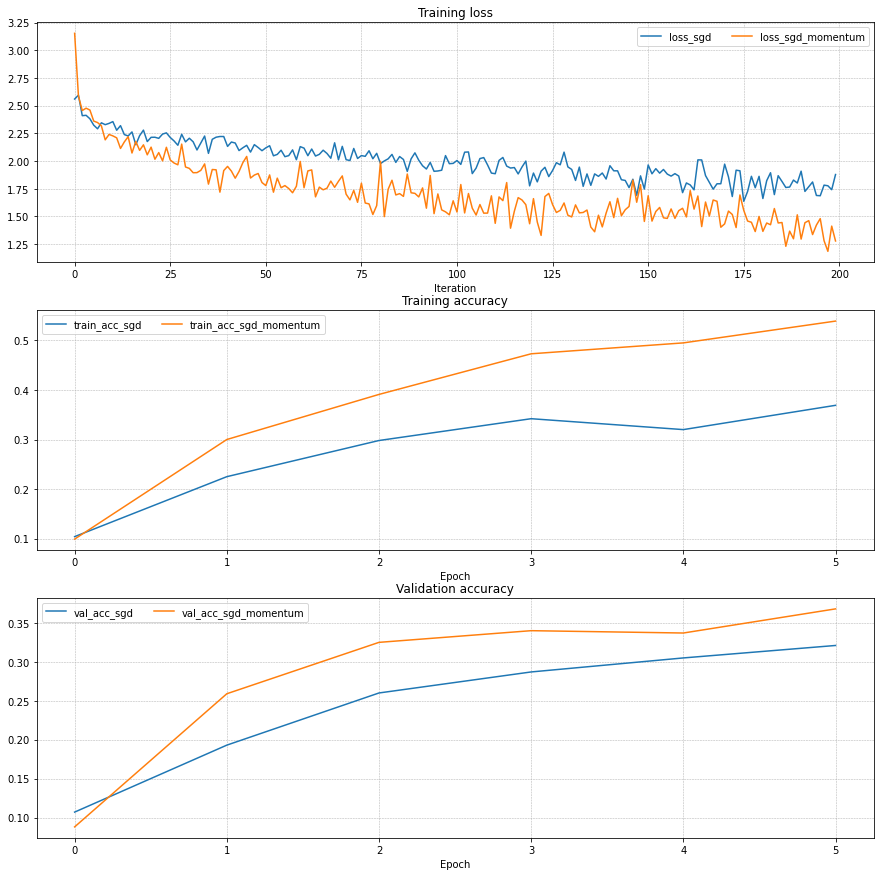

In [7]:
num_train = 4000
small_data = {
    'X_train': data['X_train'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val': data['X_val'],
    'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2,
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f'loss_{update_rule}')
    axes[1].plot(solver.train_acc_history, label=f'train_acc_{update_rule}')
    axes[2].plot(solver.val_acc_history, label=f'val_acc_{update_rule}')

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()


## 7. RMSProp and Adam

Implement `rmsprop` and `adam` in `src/optim.py`, then verify them with the reference checks below. As in the original CS231n notebook, use the full Adam update with bias correction.


In [8]:
from src.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N * D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N * D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N * D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
    [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
    [-0.132737, -0.08078555, -0.02881884, 0.02316247, 0.07515774],
    [0.12716641, 0.17918792, 0.23122175, 0.28326742, 0.33532447],
    [0.38739248, 0.43947102, 0.49155973, 0.54365823, 0.59576619],
])
expected_cache = np.asarray([
    [0.5976, 0.6126277, 0.6277108, 0.64284931, 0.65804321],
    [0.67329252, 0.68859723, 0.70395734, 0.71937285, 0.73484377],
    [0.75037008, 0.7659518, 0.78158892, 0.79728144, 0.81302936],
    [0.82883269, 0.84469141, 0.86060554, 0.87657507, 0.8926],
])

print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))


next_w error:  9.524687511038133e-08
cache error:  2.6477955807156126e-09


In [9]:
from src.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N * D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N * D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N * D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N * D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
    [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
    [-0.1380274, -0.08544591, -0.03286534, 0.01971428, 0.0722929],
    [0.1248705, 0.17744702, 0.23002243, 0.28259667, 0.33516969],
    [0.38774145, 0.44031188, 0.49288093, 0.54544852, 0.59801459],
])
expected_v = np.asarray([
    [0.69966, 0.68908382, 0.67851319, 0.66794809, 0.65738853],
    [0.64683452, 0.63628604, 0.6257431, 0.61520571, 0.60467385],
    [0.59414753, 0.58362676, 0.57311152, 0.56260183, 0.55209767],
    [0.54159906, 0.53110598, 0.52061845, 0.51013645, 0.49966],
])
expected_m = np.asarray([
    [0.48, 0.49947368, 0.51894737, 0.53842105, 0.55789474],
    [0.57736842, 0.59684211, 0.61631579, 0.63578947, 0.65526316],
    [0.67473684, 0.69421053, 0.71368421, 0.73315789, 0.75263158],
    [0.77210526, 0.79157895, 0.81105263, 0.83052632, 0.85],
])

print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))


next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


Once those optimizers are working, compare deep-network training with Adam and RMSProp. Adaptive methods typically converge faster than plain SGD on this task.


Running with  adam
(Iteration 1 / 200) loss: 3.476928
(Epoch 0 / 5) train acc: 0.126000; val_acc: 0.110000
(Iteration 11 / 200) loss: 2.027712
(Iteration 21 / 200) loss: 2.183358
(Iteration 31 / 200) loss: 1.744257
(Epoch 1 / 5) train acc: 0.363000; val_acc: 0.330000
(Iteration 41 / 200) loss: 1.707951
(Iteration 51 / 200) loss: 1.703835
(Iteration 61 / 200) loss: 2.094758
(Iteration 71 / 200) loss: 1.505558
(Epoch 2 / 5) train acc: 0.419000; val_acc: 0.362000
(Iteration 81 / 200) loss: 1.594429
(Iteration 91 / 200) loss: 1.519017
(Iteration 101 / 200) loss: 1.368522
(Iteration 111 / 200) loss: 1.470400
(Epoch 3 / 5) train acc: 0.460000; val_acc: 0.378000
(Iteration 121 / 200) loss: 1.199064
(Iteration 131 / 200) loss: 1.464705
(Iteration 141 / 200) loss: 1.359863
(Iteration 151 / 200) loss: 1.415068
(Epoch 4 / 5) train acc: 0.521000; val_acc: 0.374000
(Iteration 161 / 200) loss: 1.382818
(Iteration 171 / 200) loss: 1.359900
(Iteration 181 / 200) loss: 1.095947
(Iteration 191 / 200) lo

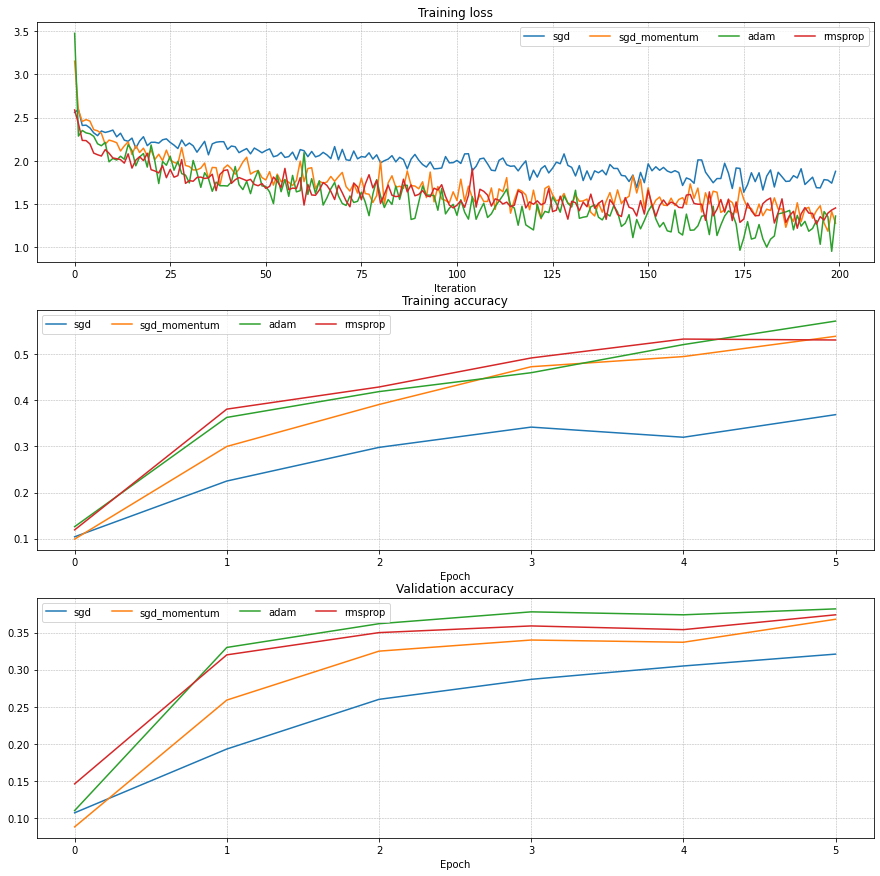

In [10]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2,
    )
    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': learning_rates[update_rule]},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()
    print()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=update_rule)
    axes[1].plot(solver.train_acc_history, label=update_rule)
    axes[2].plot(solver.val_acc_history, label=update_rule)

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()


### Inline Question 2

AdaGrad uses the update rule

```python
cache += dw ** 2
w += -learning_rate * dw / (np.sqrt(cache) + eps)
```

Why can AdaGrad's updates become very small over time? Would Adam have the same issue?

**Answer.**

AdaGrad keeps adding squared gradients into `cache`, so the denominator grows monotonically. Even if the current gradient stays informative, the effective step size keeps shrinking because it is divided by a larger and larger accumulated history. That can make learning stall.

Adam is much less prone to that exact failure mode because it uses **exponentially decaying moving averages** of both the gradient and the squared gradient. In other words, Adam forgets old information instead of accumulating it forever, so the denominator does not grow without bound in the same way.


## 8. Train a strong fully connected model

Now train the best fully connected model you can on CIFAR-10 and store it in `best_model`. A reasonable target is **at least 50% validation accuracy**; with careful tuning, higher results are possible.

This repo version keeps the search intentionally small so it stays within roughly **5 minutes** on a typical local setup. Expand the grid later if you want a stronger model.


In [11]:
best_model = None
best_val_acc = -1.0
best_stats = None

hidden_configs = [
    [100, 100],
    [100, 100, 100],
]
learning_rates = [1e-3, 2e-3]
weight_scales = [1e-2]
regularization_strengths = [0.1]
update_rules = ['adam']

for hidden_dims in hidden_configs:
    for lr in learning_rates:
        for weight_scale in weight_scales:
            for reg in regularization_strengths:
                for update_rule in update_rules:
                    model = FullyConnectedNet(
                        hidden_dims,
                        reg=reg,
                        weight_scale=weight_scale,
                    )

                    solver = Solver(
                        model,
                        data,
                        update_rule=update_rule,
                        optim_config={'learning_rate': lr},
                        lr_decay=0.95,
                        num_epochs=6,
                        batch_size=200,
                        print_every=100,
                        verbose=False,
                    )
                    solver.train()

                    train_acc = solver.train_acc_history[-1]
                    val_acc = solver.best_val_acc

                    print(
                        f'hidden_dims={hidden_dims}, lr={lr}, weight_scale={weight_scale}, '
                        f'reg={reg}, update_rule={update_rule}, '
                        f'train_acc={train_acc:.4f}, val_acc={val_acc:.4f}'
                    )

                    if val_acc > best_val_acc:
                        best_val_acc = val_acc
                        best_model = model
                        best_stats = {
                            'hidden_dims': hidden_dims,
                            'learning_rate': lr,
                            'weight_scale': weight_scale,
                            'reg': reg,
                            'update_rule': update_rule,
                            'train_acc': train_acc,
                            'val_acc': val_acc,
                        }

print('best_val_acc:', best_val_acc)
print('best_stats:', best_stats)


hidden_dims=[100, 100], lr=0.001, weight_scale=0.01, reg=0.1, update_rule=adam, train_acc=0.4360, val_acc=0.4480
hidden_dims=[100, 100], lr=0.002, weight_scale=0.01, reg=0.1, update_rule=adam, train_acc=0.3670, val_acc=0.3890
hidden_dims=[100, 100, 100], lr=0.001, weight_scale=0.01, reg=0.1, update_rule=adam, train_acc=0.4350, val_acc=0.4300
hidden_dims=[100, 100, 100], lr=0.002, weight_scale=0.01, reg=0.1, update_rule=adam, train_acc=0.3680, val_acc=0.3910
best_val_acc: 0.448
best_stats: {'hidden_dims': [100, 100], 'learning_rate': 0.001, 'weight_scale': 0.01, 'reg': 0.1, 'update_rule': 'adam', 'train_acc': 0.436, 'val_acc': 0.448}


## 9. Final evaluation

Run the best model on the validation and test sets. As in the earlier notebooks, saving the final model makes it easy to reuse later without retraining.


In [12]:
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)

print('Validation set accuracy: ', np.mean(y_val_pred == data['y_val']))
print('Test set accuracy: ', np.mean(y_test_pred == data['y_test']))


Validation set accuracy:  0.448
Test set accuracy:  0.421


In [13]:
# Save best model
best_model.save('best_fully_connected_net.npy')


best_fully_connected_net.npy saved.


## 10. Takeaways

This notebook extends the earlier two-layer network exercise in two important ways:

- **depth** gives the model more expressive power, but also makes optimization more fragile;
- **optimizer choice** matters much more once the network gets deeper;
- **small-set overfitting tests** are one of the fastest ways to debug an implementation;
- **gradient checks** are still the most reliable correctness check before large training runs.

That combination of modular implementation and careful optimization is the main lesson of the fully connected network assignment.
